In [1]:
import pickle
import numpy as np
import pandas as pd
import urllib.request
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

In [2]:
url_train = "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset/Train/Monthly-train.csv"
url_test  = "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset/Test/Monthly-test.csv"

try:
    urllib.request.urlretrieve(url_train, DATA_DIR / "monthly_train.csv")
    urllib.request.urlretrieve(url_test,  DATA_DIR / "monthly_test.csv")
    print("Download complete.")
except Exception as e:
    print(f"Download failed: {e}")
    print("Check your internet connection and retry.")

Download complete.


In [3]:
try:
    train = pd.read_csv(DATA_DIR / "monthly_train.csv", index_col=0)
    test  = pd.read_csv(DATA_DIR / "monthly_test.csv",  index_col=0)
    print(f"Train shape: {train.shape}")
    print(f"Test shape:  {test.shape}")
except FileNotFoundError as e:
    print(f"CSV file not found: {e}")
except Exception as e:
    print(f"Error reading data: {e}")

Train shape: (48000, 2794)
Test shape:  (48000, 18)


In [4]:
N_SERIES = 1000
FORECAST_HORIZON = 18

train_sub = train.iloc[:N_SERIES]
test_sub  = test.iloc[:N_SERIES]

series_list = []
for idx in train_sub.index:
    try:
        s = train_sub.loc[idx].dropna().values.astype(float)
        if len(s) < 24:
            continue
        series_list.append(s)
    except Exception as e:
        print(f"Skipping series {idx}: {e}")
        continue

lengths = [len(s) for s in series_list]
print(f"Series count:    {len(series_list)}")
print(f"Min length:      {min(lengths)}")
print(f"Max length:      {max(lengths)}")
print(f"Median length:   {int(np.median(lengths))}")

Series count:    1000
Min length:      61
Max length:      1230
Median length:   306


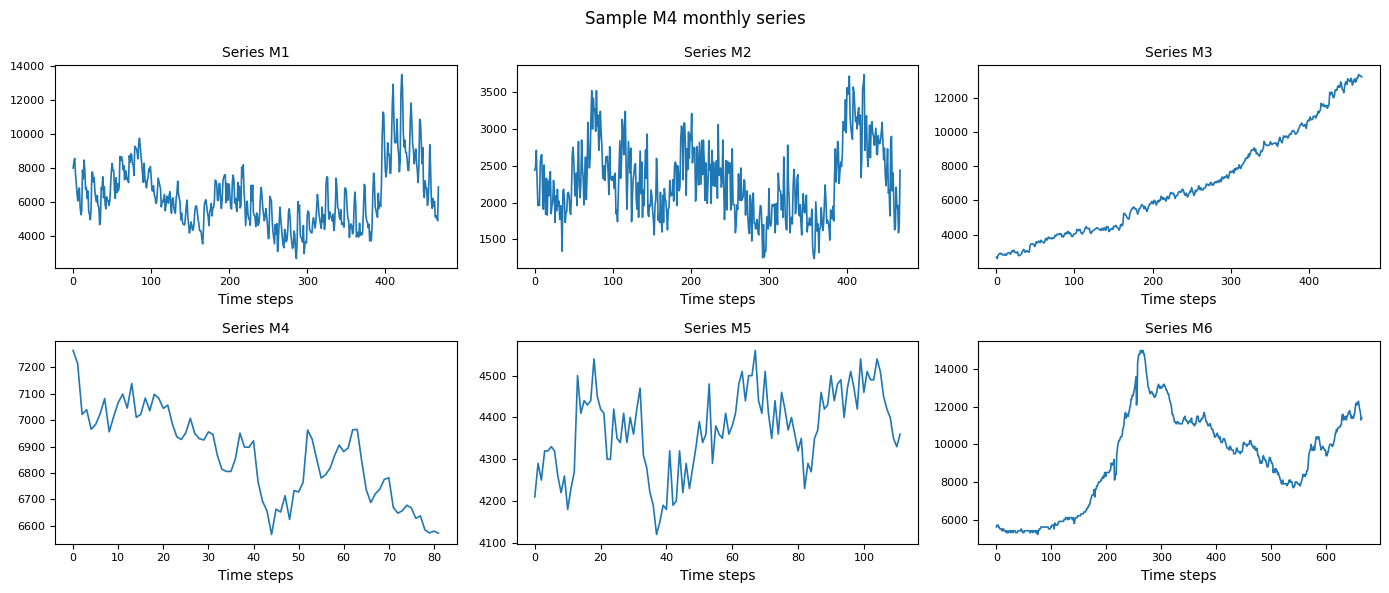

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    try:
        ax.plot(series_list[i], linewidth=1.2)
        ax.set_title(f"Series {train_sub.index[i]}", fontsize=10)
        ax.set_xlabel("Time steps")
        ax.tick_params(labelsize=8)
    except Exception as e:
        ax.set_title(f"Series {i} — error")
        continue
plt.suptitle("Sample M4 monthly series", fontsize=12)
plt.tight_layout()
try:
    plt.savefig("data/sample_series.png", dpi=100)
except Exception as e:
    print(f"Could not save plot: {e}")
plt.show()

In [6]:
try:
    with open(DATA_DIR / "series_list.pkl", "wb") as f:
        pickle.dump(series_list, f)
    with open(DATA_DIR / "test_sub.pkl", "wb") as f:
        pickle.dump(test_sub.values[:, :FORECAST_HORIZON].astype(float), f)
    print("Saved series_list.pkl and test_sub.pkl")
except Exception as e:
    print(f"Failed to save data: {e}")

Saved series_list.pkl and test_sub.pkl
